# Assignment 1 -- ML4F 2023

## Instructions
* This assignment covers the material discussed in Lectures ML1 - ML4. 
* Each group submits _only one_ notebook via canvas on the assignment page. 
* The notebook should be named `assignment1_groupXX.ipynb` where `XX` is your group number,  
e.g. for group 3 this will be `assignment1_group03.ipynb`.
* The notebook should run without raising any errors. 
* We recommend keeping the folder structure
```
assignment/
    data/
    lib/
    assignment1_groupXX.ipynb
```
* We strongly recommend git, as you are encouraged to collaborate and split up the work and maybe even start independently. To see how to set up your own repo for your group, see `VU Workshop Introduction to Version Control with GIT.pptx` discussed in week 2.
* Do not spend time on optimizing the speed of your code. However, if it runs for more than 5 minutes, we will terminate it.
* We strongly encourage you to experiment, try different approaches and combinations and get to know the problem from alternative angles. But the final notebook should only contain the necessary results for grading.
----

<div style="font-size:24px; text-align:center; font-weight:bold">Good luck!</div>

----

# Assignment 1 - Features & Algorithms

Kiwibank, a commercial bank from New Zealand, is interested in updating their loan default prediction algorithm. They used to check each client manually, and now they want to use Machine Learning to predict who will default on their loan and pose a threat to the bank's balance sheet. They have supplied you with a dataset of their past clients, and they've asked you to consult them on their adaptation of Machine Learning in this process.

First take a look at the data, then test different algorithms, select key features and write a recommendation to the bank.

State your imports below.

In [44]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef,classification_report,roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Preprocessing (15 points)
*5 points for correct code*

*10 points for normalization procedure*

The data consists of 34 features and one target variable, 'Loan Status'
We have 25 numerical features and 9 categorical features. For the numerical features, apply a technique
to make the data more normal. This can be Standardization, Normalization, log or a Box-Cox transformation. 
Explain why you might use one method for some features, and another for other features.
Also check for missing values and uninformative features (NO FEATURE SELECTION YET).

In [5]:
data = pd.read_csv('8_ML4F_Assignment1Data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    10000 non-null  int64  
 1   ID                            10000 non-null  int64  
 2   Loan Amount                   10000 non-null  int64  
 3   Funded Amount                 10000 non-null  int64  
 4   Funded Amount Investor        10000 non-null  float64
 5   Term                          10000 non-null  int64  
 6   Batch Enrolled                10000 non-null  object 
 7   Interest Rate                 10000 non-null  float64
 8   Grade                         10000 non-null  object 
 9   Sub Grade                     10000 non-null  object 
 10  Employment Duration           10000 non-null  object 
 11  Home Ownership                10000 non-null  float64
 12  Verification Status           10000 non-null  object 
 13  Pa

(array([   7.,   11.,   23.,   28.,   33.,   80.,  114.,  158.,  241.,
         333.,  439.,  552.,  617.,  678.,  764., 1539., 1336., 1120.,
         800., 1127.]),
 array([ 6.93731408,  7.11357354,  7.28983299,  7.46609244,  7.6423519 ,
         7.81861135,  7.9948708 ,  8.17113026,  8.34738971,  8.52364917,
         8.69990862,  8.87616807,  9.05242753,  9.22868698,  9.40494644,
         9.58120589,  9.75746534,  9.9337248 , 10.10998425, 10.28624371,
        10.46250316]),
 <BarContainer object of 20 artists>)

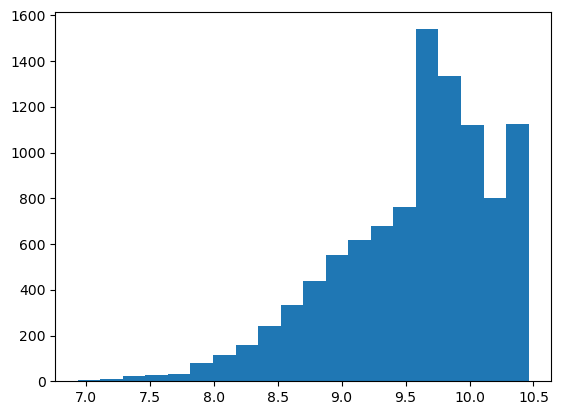

In [21]:
plt.hist(np.log(data['Loan Amount']), bins=20)

In [27]:
data_pp = pd.DataFrame(index=data.ID, columns=['Loan Amount','Funded Amount','Funded Amount Investor','Home Ownership','Debit to Income','Revolving Balance','Revolving Utilities','Total Accounts','Total Received Interest','Total Received Late Fee','Recoveries','Collection Recovery Fee','Last week Pay','Total Collection Amount','Total Current Balance','Total Revolving Credit Limit'])

In [33]:
data_pp = data[['Loan Amount','Funded Amount','Funded Amount Investor','Home Ownership','Debit to Income','Revolving Balance','Revolving Utilities','Total Accounts','Total Received Interest','Total Received Late Fee','Recoveries','Collection Recovery Fee','Last week Pay','Total Collection Amount','Total Current Balance','Total Revolving Credit Limit']]

In [40]:
data_pp1 = preprocessing.normalize(data_pp, norm='l2')
df_normalized = pd.DataFrame(data_pp1)
df_normalized.columns = data_pp.columns
df_normalized

,Loan Amount,Funded Amount,Funded Amount Investor,Home Ownership,Debit to Income,Revolving Balance,Revolving Utilities,Total Accounts,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Last week Pay,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit
0,0.113610,0.120614,0.076472,0.918404,0.000084,0.008028,0.000562,0.000100,0.002294,2.448296e-07,3.682838e-05,1.178656e-06,0.000358,0.000315,0.347648,0.047979
1,0.076477,0.013357,0.042696,0.466582,0.000076,0.001980,0.000135,0.000040,0.003387,1.995669e-07,2.944779e-05,8.642202e-07,0.000040,0.000127,0.879615,0.026714
2,0.048915,0.138669,0.059368,0.631686,0.000070,0.000084,0.000027,0.000105,0.009491,1.983271e-07,1.406242e-05,5.768675e-06,0.000272,0.000109,0.758672,0.012347
3,0.068476,0.028199,0.029685,0.576181,0.000125,0.032202,0.000089,0.000100,0.002200,5.445202e-07,3.446890e-05,2.290142e-06,0.000614,0.000207,0.809500,0.072922
4,0.219603,0.084917,0.042257,0.360006,0.000241,0.058479,0.000560,0.000125,0.017286,2.655374e-08,1.981321e-05,8.706047e-06,0.000743,0.000303,0.898253,0.050947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.036428,0.020108,0.015445,0.092728,0.000028,0.008275,0.000104,0.000029,0.000782,1.120500e-07,9.683269e-07,1.237952e-06,0.000033,0.000095,0.994533,0.016313
9996,0.038959,0.033611,0.030575,0.276667,0.000063,0.018961,0.000114,0.000029,0.009618,1.382884e-07,9.980967e-09,1.610665e-07,0.000033,0.000078,0.957408,0.052829
9997,0.078331,0.173360,0.071587,0.391933,0.000113,0.048055,0.000046,0.000048,0.014704,1.020232e-07,6.913503e-08,5.306328e-06,0.000348,0.000086,0.882269,0.155405
9998,0.056599,0.018373,0.026377,0.149823,0.000033,0.050386,0.000100,0.000052,0.001347,7.501163e-08,1.246426e-05,1.513315e-06,0.000326,0.000092,0.984903,0.027252


(array([3783., 3013., 1572.,  803.,  449.,  232.,  113.,   24.,    7.,
           4.]),
 array([0.0036238 , 0.06946027, 0.13529675, 0.20113322, 0.2669697 ,
        0.33280618, 0.39864265, 0.46447913, 0.5303156 , 0.59615208,
        0.66198856]),
 <BarContainer object of 10 artists>)

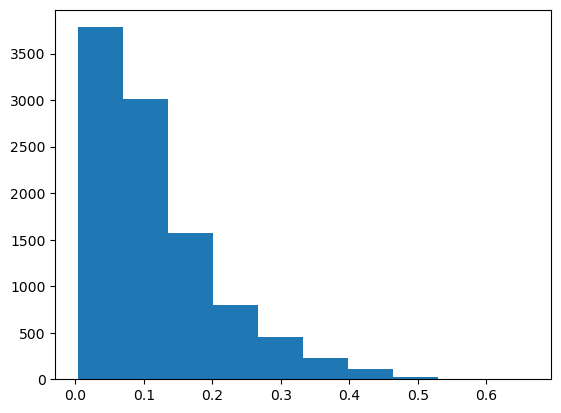

In [41]:
plt.hist(df_normalized['Loan Amount'])

In [49]:
data_pp2 = StandardScaler().fit_transform(data_pp.values)
df_standardized = pd.DataFrame(data_pp2)
df_standardized.columns = data_pp.columns
df_standardized

,Loan Amount,Funded Amount,Funded Amount Investor,Home Ownership,Debit to Income,Revolving Balance,Revolving Utilities,Total Accounts,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Last week Pay,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit
0,-0.103757,0.149881,-0.571898,1.064635,-1.360944,-0.866174,1.136524,-0.545010,-0.788428,-0.207180,-0.154205,-0.281321,-0.489957,-0.142053,-0.787155,-0.780309
1,1.158060,-1.350154,0.035964,1.806642,0.335029,-0.924597,-0.274894,-0.545010,-0.408131,-0.200401,-0.140536,-0.239479,-1.322152,-0.142053,1.067000,-0.661471
2,-0.602668,2.146082,-0.052201,1.570170,-0.769888,-1.013704,-2.045434,0.802357,0.081010,-0.204619,-0.159044,0.096450,-0.143209,-0.167660,0.174348,-0.955854
3,-0.026882,-1.082742,-1.095386,1.303618,0.816143,0.023963,-1.380041,0.679869,-0.694532,-0.188284,-0.145618,-0.160592,1.775463,-0.133518,0.276107,-0.271175
4,1.984255,-0.332909,-1.204406,-0.581854,1.576513,0.174843,1.434046,0.067430,0.242686,-0.213048,-0.159981,0.079673,0.966384,-0.139208,-0.148998,-0.731417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.745321,-0.359785,-0.710374,-0.496936,-0.639395,-0.316656,0.565240,-0.055058,-0.711163,-0.200072,-0.166488,-0.089231,-1.160337,-0.119292,3.412060,-0.612111
9996,0.087417,-0.067583,-0.121342,0.970693,0.575885,0.122852,-0.063136,-0.667498,0.995466,-0.201767,-0.168133,-0.310095,-1.299036,-0.154857,1.973778,0.014505
9997,-0.250236,2.058090,-0.170973,-0.167468,-0.257244,0.186768,-1.952960,-1.157450,0.296093,-0.210124,-0.168110,-0.023749,-0.143209,-0.181885,0.056202,0.264768
9998,1.090125,-0.886018,-0.366263,-0.273152,-0.975154,2.071024,-0.309871,0.679869,-0.656287,-0.207158,-0.152695,-0.117027,1.798580,-0.144899,2.126739,-0.510724


(array([ 142.,  377.,  547.,  647.,  665.,  582.,  569.,  625., 1010.,
         689.,  699.,  749.,  510.,  287.,  265.,  258.,  404.,  422.,
         319.,  234.]),
 array([-1.87187474, -1.66956322, -1.4672517 , -1.26494018, -1.06262866,
        -0.86031714, -0.65800563, -0.45569411, -0.25338259, -0.05107107,
         0.15124045,  0.35355197,  0.55586349,  0.75817501,  0.96048652,
         1.16279804,  1.36510956,  1.56742108,  1.7697326 ,  1.97204412,
         2.17435564]),
 <BarContainer object of 20 artists>)

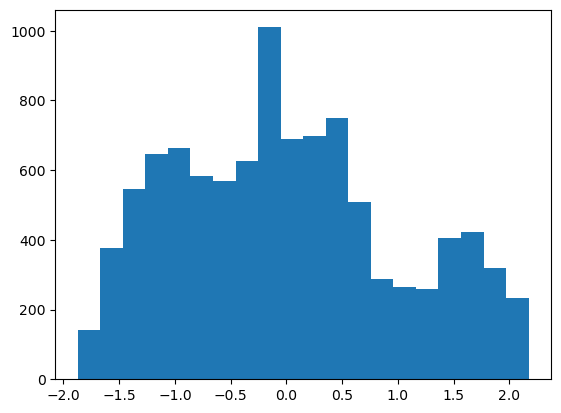

In [52]:
plt.hist(df_standardized['Loan Amount'], bins=20)

# Training (30 points)
*10 points for correct code*

*10 points for interpretation results*

*10 points for pitfalls*

We've familiarized ourselves with the data, so now we're going to train some models.
A handful of frequently used models are: Decision Trees (DTC), Nearest Neighbors (KNN) and
Stochastic Gradient Descent learning algorithm (SGD).
Split the data into a training set and a test set, and train all mentioned models on the data.
For KNN, find the optimal number of neighbors. 
Use the test set to get the predicted values. Show the performance of the different models in a Confusion Matrix and compare the accuracy, precision, recall and F1-score.

When looking at the resulting measures and matrices, what stands out? What possible pitfalls may be hiding in each of the models?

# Feature Selection (35 points)
*10 points for correct code*

*15 points for correct reasoning and interpretation*

*10 points for explanation pitfalls*

Now that we've compared the performance of the different models, we place our judgement upon 
the dimensionality of the data. The dimension reduction methods discussed so far are 
L2 regularization and LASSO. Combining these methods gives us the Elastic Net method. What are some pitfalls of L2 regularization and of LASSO? How does Elastic Net overcome these pitfalls?

The Elastic Net method uses two parameters, l1_ratio and α. l1_ratio takes on a value between 0 and 1, and α a value higher than 0. Use the Elastic Net method to get an impression of the importance of the features, and make 
an appropriate and argumented decision regarding their individual inclusion.

# Recommendation (10 points)
*10 points for paper*

Now that you've made an assessment of the key features and it is clear which model performs best, it is time to write a recommendation to Kiwibank. Explain what you have researched and present your results in a short paper in no more than 400 words. 

Focus on the bank's wants and needs, and minimize the technical talk. We recommend writing in LaTeX/Overleaf, but Word or another application is also fine. Hand the paper in as PDF, together with your Jupyter Notebook, in a ZIP-file.